In [ ]:
# libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import os
import numpy as np
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# parameters
latent_dim = 100
batch_size = 64
epochs = 50
lr = 0.0002
betas = (0.5, 0.999)
image_size = 28 * 28   # 784

In [ ]:
os.makedirs("gan_samples", exist_ok=True)

In [ ]:
# load data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(mnist, batch_size=batch_size, shuffle=True, drop_last=True)

First we load the mnist dataset and then normalise it.

In [ ]:
# generator
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, output_dim),
            nn.Tanh()
        )

    def forward(self, z):
        # z: (batch, latent_dim)
        return self.model(z)


This is a simple fully-connected GAN generator. For image generation tasks like faces or high-resolution images, modern GANs usually replace these Linear layers with ConvTranspose2d (deconvolution) layers to preserve spatial structure.

In [ ]:
# discriminator
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, input_dim)
        return self.model(x)

This code defines the Discriminator network of a GAN (Generative Adversarial Network). Its purpose is to classify whether an input sample is real (from the training dataset) or fake (generated by the Generator).

In [ ]:
# initialize models, optimizers, and loss
generator = Generator(latent_dim, image_size).to(device)
discriminator = Discriminator(image_size).to(device)

optim_G = optim.Adam(generator.parameters(), lr=lr, betas=betas)
optim_D = optim.Adam(discriminator.parameters(), lr=lr, betas=betas)

criterion = nn.BCELoss()

# Fixed noise for consistent visualization across epochs
fixed_noise = torch.randn(64, latent_dim, device=device)

In [ ]:
# training
print("Starting training...")
for epoch in range(epochs):
    for batch_idx, (real_imgs, _) in enumerate(dataloader):
        batch_size_curr = real_imgs.size(0)
        real_imgs = real_imgs.view(batch_size_curr, -1).to(device)  # flatten


        # train discriminator

        # real labels = 1, fake labels = 0
        real_labels = torch.ones(batch_size_curr, 1, device=device)
        fake_labels = torch.zeros(batch_size_curr, 1, device=device)

        # train on real images
        optim_D.zero_grad()
        outputs_real = discriminator(real_imgs)
        loss_real = criterion(outputs_real, real_labels)

        # train on fake images
        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_imgs = generator(noise).detach()
        outputs_fake = discriminator(fake_imgs)
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optim_D.step()


        # train Generator
        optim_G.zero_grad()

        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_imgs = generator(noise)
        outputs = discriminator(fake_imgs)
        # we want the discriminator to think these are real -> label = 1
        loss_G = criterion(outputs, real_labels)
        loss_G.backward()
        optim_G.step()


    print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {loss_D.item():.4f}  Loss G: {loss_G.item():.4f}")

    # generate images from the fixed noise and save them
    with torch.no_grad():
        generated = generator(fixed_noise).view(-1, 1, 28, 28)
        save_image(generated, f"gan_samples/epoch_{epoch+1:03d}.png", nrow=8, normalize=True)

print("Training finished!")


This code trains the Generator and Discriminator in a GAN. The training process alternates between improving the Discriminator (detecting real vs fake images) and improving the Generator (creating images that fool the Discriminator).

Starting training...
Epoch [1/50]  Loss D: 0.5936  Loss G: 4.2996
Epoch [2/50]  Loss D: 0.2963  Loss G: 3.4376
Epoch [3/50]  Loss D: 0.4119  Loss G: 1.6727
Epoch [4/50]  Loss D: 0.5350  Loss G: 1.9897
Epoch [5/50]  Loss D: 0.3944  Loss G: 2.1202
Epoch [6/50]  Loss D: 0.8487  Loss G: 1.8140
Epoch [7/50]  Loss D: 0.7277  Loss G: 1.7918
Epoch [8/50]  Loss D: 0.9679  Loss G: 1.4013
Epoch [9/50]  Loss D: 0.9784  Loss G: 1.2549
Epoch [10/50]  Loss D: 1.0016  Loss G: 1.2408
Epoch [11/50]  Loss D: 1.0462  Loss G: 1.2348
Epoch [12/50]  Loss D: 1.1164  Loss G: 1.0335
Epoch [13/50]  Loss D: 1.0736  Loss G: 1.5233
Epoch [14/50]  Loss D: 1.1386  Loss G: 0.9252
Epoch [15/50]  Loss D: 1.2043  Loss G: 1.2778
Epoch [16/50]  Loss D: 1.1330  Loss G: 1.0981
Epoch [17/50]  Loss D: 1.2662  Loss G: 1.2090
Epoch [18/50]  Loss D: 1.1984  Loss G: 1.2656
Epoch [19/50]  Loss D: 1.2042  Loss G: 1.0087
Epoch [20/50]  Loss D: 0.9872  Loss G: 0.8716
Epoch [21/50]  Loss D: 1.1255  Loss G: 1.1827
Epoch [22/50]  Loss D:

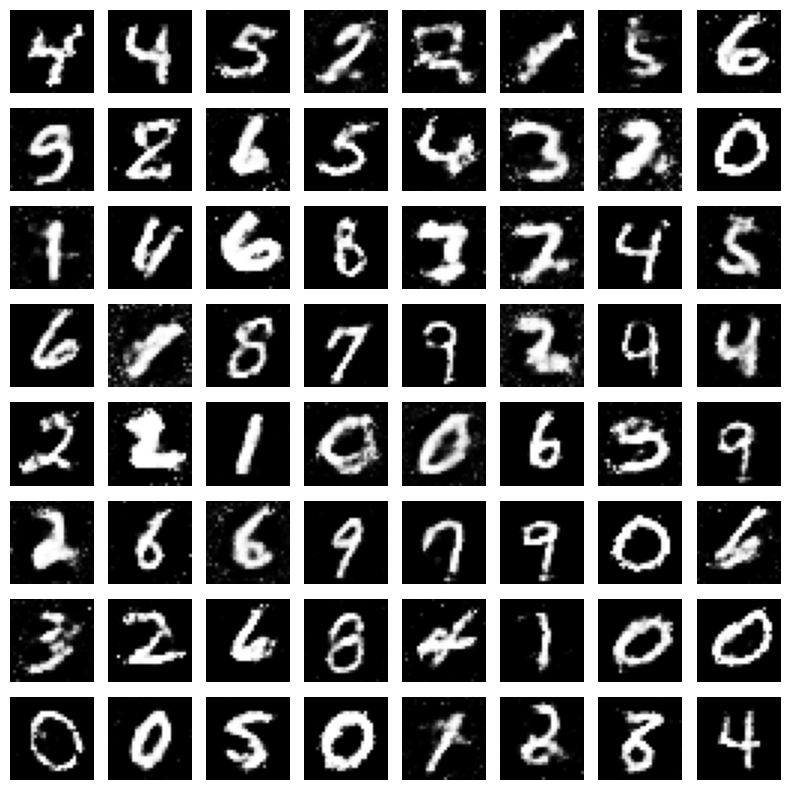

In [11]:
# visualize
with torch.no_grad():
    final_samples = generator(fixed_noise).view(-1, 1, 28, 28).cpu().numpy()

plt.figure(figsize=(8, 8))
for i in range(64):
    plt.subplot(8, 8, i+1)
    plt.imshow(final_samples[i, 0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.savefig("final_samples.png")
plt.show()

We can see the results, the model has created numbers from the dataset.

## 1. Why can GANs potentially suffer from mode collapse?

**Mode collapse** occurs when the Generator learns to produce a very limited variety of outputs (e.g., only the digit "1" on MNIST, or only one specific face orientation) instead of covering the full diversity (all "modes") of the training data.

Here is why this *can* happen:

### 1. The "Fool the Discriminator" Incentive
- The Generator's primary goal is to maximize the Discriminator's error.
- If the Generator discovers a single type of fake image that consistently fools the Discriminator, it has **no inherent incentive** to explore other types.
- Exploring new types might produce lower-quality images that the Discriminator easily spots, increasing the Generator's loss. Sticking to the "winning" mode is simply a locally optimal strategy.

### 2. The Discriminator "Forgetting" Problem
- When the Generator starts to collapse, it stops producing other modes.
- The Discriminator, trained on only the *current* batch of fakes, will quickly learn to reject that specific collapsed mode.
- **The trap:** Because the Generator is also updated, it simply shifts the collapsed output slightly to a new variation to fool the Discriminator again.
- This creates a "cat-and-mouse" chase where the Generator drifts across the data space, but never expands its coverage—it just shifts a single peak around.

### 3. Nash Equilibrium Traps (Local Equilibria)
- In game theory, the ideal solution is a **global Nash equilibrium** where the Generator perfectly matches the real data distribution.
- However, the GAN objective is **non-convex**. This means there exist many **local Nash equilibria**.
- In a collapsed equilibrium, the Generator covers one mode, and the Discriminator is too weak to push it out. The gradient signal for the Generator to move *away* from this mode is weak, effectively trapping it.

### 4. Vanishing Gradients in "Saturation"
- If the Discriminator becomes too powerful, it rejects the Generator's outputs with near-certainty (probability $ \approx 0 $).
- The original GAN loss for the Generator, $ \log(1 - D(G(z))) $, saturates—the gradient approaches zero.
- If the gradient vanishes, the Generator stops learning and freezes. If it froze while producing only one mode, permanent mode collapse sets in.

### 5. Minimizing Divergence vs. Covering Modes
- The standard GAN implicitly minimizes the **Jensen-Shannon (JS) divergence** between the real distribution $P_{data}$ and the generated distribution $P_{g}$.
- If $P_{g}$ misses a mode but perfectly reproduces the rest, the JS divergence might still be relatively low.
- It is computationally "cheaper" for the Generator to focus its limited capacity on perfecting one mode rather than spreading its capacity thinly over 10 modes and doing a mediocre job on all of them.

---

## 2. Why is there no formal guarantee that mode collapse will occur?


### 1. The GAN Game is Non-Convex
- For gradient descent to have formal convergence guarantees (and to guarantee a specific outcome like collapse), the optimization problem must be **convex-concave**.
- In a convex-concave game (e.g., traditional SVM), gradient descent will provably reach the global optimum.
- The GAN objective is **highly non-convex** because both networks use non-linear activations.
- In non-convex games, there is **no mathematical theorem** stating that gradient descent must converge to any particular fixed point (collapsed or not). It could converge to a global optimum, a local optimum, or chaos.

### 2. Stochasticity of Mini-Batch Training
- We don't use the true gradient (which would require the entire dataset); we use **Stochastic Gradient Descent (SGD)** with mini-batches.
- This introduces noise into the gradient estimates.
- Interestingly, this noise can sometimes *rescue* the generator from collapse—because the random fluctuations can "kick" it out of a local collapsed trap.
- Since the process is stochastic, we cannot formally prove it will deterministically collapse; the outcome is probabilistic.

### 3. Infinite Capacity vs. Finite Capacity Networks
- The formal proof of the GAN's optimality (where $P_{g} = P_{data}$) assumes both networks have **infinite capacity** (can approximate any function) and that we perform *global* optimization.
- In practice, we use finite neural networks and local gradient steps.
- Because we deviate from these ideal mathematical assumptions, the theoretical "guarantees" break down. We cannot guarantee collapse because we aren't even guaranteed to reach the theoretical equilibrium at all!

### 4. Empirical Counter-Examples
- State-of-the-art models (like StyleGAN or BigGAN) show that with careful architectural choices, regularization, and tuning, mode collapse can be largely avoided.
- If mode collapse were a mathematically *guaranteed* outcome, these diverse, high-quality models would be impossible. Since they exist, we know empirically that collapse is a *possible failure mode*, not a *mathematical certainty*.

### 5. The "Helvetica Scenario" is just one of many equilibria
- In the famous "Helvetica" example (where the generator learns to output a single perfect image), this is indeed a valid local Nash equilibrium *for a specific discriminator state*.
- However, there are infinitely many other possible equilibria.
- Proving that the training dynamics *must* converge to the collapsed one (rather than the global one) would require solving the entire non-linear dynamical system, which is mathematically intractable.

